## 模拟退火
模拟退火算法的出发点是基于物理中固体物质的退火过程与一般的组合优化问题之间存在相似性。  
首先，物理退火过程由以下三部分组成：  
1. 加温过程。目的是增强粒子的热运动，使其偏离平衡位置。当温度足够高时，固体将变为液体从而消除系统原先存在的非均匀状态。
2. 等温过程：对于与周围环境交换热量而温度不变的封闭系统，系统状态的自发变化总是朝自由能减少的方向进行的，当自由能达到最小时，系统达到平衡状态
3. 冷却过程：使粒子热运动减弱，系统能量下降，得到晶体结构
加温过程对应算法的设定初始温度，等温过程对应算法的Metropolis抽样过程,冷却过程对应控制参数的下降。这里能量的变化就是目标函数,要得到的最优解就是能量最低态。Metropolis准则是SA算法收敛于全局最优解的关键所在,Metropolis准则以一定的概率接受恶化解,这样就使算法跳离局部最优的陷阱。
模拟退火算法为求解传统方法难处理的TSP问题提供了一个有效的途径和通用框架，并逐渐发展成一种迭代自适应启发式概率性搜索算法。模拟退火算法可以用以求解不同的非线性问题,对不可微甚至不连续的函数优化,能以较大概率求得全局优化解。该算法还具有较强的鲁棒性、全局收敛性、隐含并行性及广泛的适应性,并且能处理不同类型的优化设计变量(离散的、连续的和混合型的)，不需要任何的辅助信息，对目标函数和约束函数没有任何要求。

### 实现过程  
1. 初始化：取初始温度 $T_0$ 足够大，令 $T=T_0$ ，任取初始解 $S_1$ ，确定每个 $T$ 时的迭代次数，即Metropolis链长$L$
2. 对当前温度 $T$ 和 $k=1,2,...,L$ ，重复步骤3到6
3. 对当前解 $S_1$ 随机扰动生成一个新解 $S_2$ 
4. 计算 $S_2$ 的增量 $df=f(S_2)-f(S_1)$ ，其中 $f(S_1)$ 为 $S_1$ 的代价函数
5. 若$df<0$，则接受 $S_2$ 作为新的当前解，即 S_1=S_2 ；否则计算 S_2 的接受概率 $exp(-df/T)$ ，即随机产生 $(0,1)$ 区间上均匀分布的随机数 $rand$，若 $exp(-df/T)>rand$，也接受 $S_2$ 作为新的当前解， $S_1=S_2$ ；否则保留当前解 $S_1$ 。
6. 若满足终止条件Stop，则输出当前解 $S_1$ 为最优解，结束程序。Stop条件通常设置为：在连续若干个Metropolis链中新解 $S_2$ 都没有被接受。或者是设定一个结束温度。否则对温度进行衰减后回到步骤2

### 算法实现
1. 控制参数的设置：
   需要设置的参数有降温速率 $q$ ，初始温度 $T_0$ ，结束温度 $T_end$ 以及链长 $L$(链长代表了各温度下的迭代次数)
2. 初始解：
   对于TSP问题，解空间就是由n个数字排列成的序列组成的空间，随机将n个城市进行排列得到初始解
3. 解变换生成新解
   本实验采用的新解生成方式是随机挑选两个城市进行对换
4. Metropolis准则
   若路径长度为 $f(S)$ ，则当前解的路径为 $f(S_1)$ ，新解的路径为 $f(S_2)$ ，路径差为 $df=f(S_2)-f(S_1)$ ，则Metropolis准则为：
   $$
   \text{P}=
    \begin{cases}
        e^{-df/T}, & df \ge 0,\\
        1, & df < 0.
    \end{cases}
   $$
5. 降温
   利用降温速率 $q$ 进行降温，即 $T=qT$ ，若T小于结束温度，则停止迭代输出当前状态，否则继续迭代


In [1]:
# 这里使用蚁群算法中常用的城市创建和距离计算方法

import numpy as np
import matplotlib.pyplot as plt

# 创建城市位置
# 输入：城市数量size，坐标范围low_range到high_range
# 输出：城市坐标数组cities，形状为(size, 2)
def create_cities(size, low_range, high_range):
    cities = np.zeros((0, 2))
    i,j = 0,0
    while i < size:
        x = np.random.randint(low_range, high_range)
        y = np.random.randint(low_range, high_range)
        if not np.any(np.all(cities == [x, y], axis=1)):
            cities = np.vstack([cities, [x, y]])
            i += 1
        else:
            continue
    return cities

# 计算城市间距离矩阵
# 输入：城市坐标数组cities，形状为(size, 2)
# 输出：距离矩阵distance_matrix，形状为(size, size)
def caculate_distance(cities):
    size = cities.shape[0]
    distance_matrix = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            if i != j:
                distance = np.linalg.norm(cities[i] - cities[j])
                distance_matrix[i][j] = distance
            else:
                distance_matrix[i][j] = 1e-4
    return distance_matrix

# 可视化城市位置
# 输入：城市坐标数组cities，形状为(size, 2)
def plot_cities(cities):
    plt.figure(figsize=(8, 8))
    plt.scatter(cities[:, 0], cities[:, 1], c='blue', marker='o')
    for idx, (x, y) in enumerate(cities):
        plt.text(x, y, str(idx), fontsize=12, ha='right')
    plt.title('City Locations')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.show()

In [24]:
# 生成初始解
# 输入：城市列表cities，形状为(size, 2)
# 输出：初始路径initial_path，形状为(size,1)
def generate_initial_solution(cities):
    size = cities.shape[0]
    initial = np.arange(size)
    np.random.shuffle(initial)
    initial_path = initial.reshape(-1, 1)
    return initial_path

# 生成新解
# 输入：当前路径current_path，形状为(size, 1)
# 输出：新路径new_path，形状为(size, 1)
def generate_new_solution(current_path):
    size = current_path.shape[0]
    new_path = current_path.copy()
    a, b = np.random.choice(size, 2, replace=False)
    new_path[a], new_path[b] = current_path[b], current_path[a]
    return new_path

# 计算路径距离
# 输入：路径path，形状为(size, 1)
#      距离矩阵distance_matrix，形状为(size, size)
# 输出：路径距离total_distance
def caculate_path_distance(path, distance_matrix):
    size = path.shape[0]
    total_distance = 0
    for i in range(size - 1):
        total_distance += distance_matrix[path[i][0]][path[i + 1][0]]
    total_distance += distance_matrix[path[-1][0]][path[0][0]]
    return total_distance

# Metropolis准则
# 输入：当前解current_solution，形状为(size, 1)
#      新解new_solution，形状为(size, 1)
#      距离矩阵distance_matrix，形状为(size, size)
#      温度temperature
# 输出：下一个当前解next_solution，形状为(size, 1)
#      下一个当前解的路线距离
def metropolis_criteria(current_solution, new_solution, distance_matrix, temperature):
    current_distance = caculate_path_distance(current_solution, distance_matrix)
    new_distance = caculate_path_distance(new_solution, distance_matrix)
    if new_distance < current_distance:
        return new_solution, new_distance
    else:
        acceptance_probability = np.exp((current_distance - new_distance) / temperature)    # 负号乘进括号内
        if np.random.rand() < acceptance_probability:
            return new_solution, new_distance
        else:
            return current_solution, current_distance

# 路径长度记录可视化
# 输入：路径长度记录distance_record，np列表
def plot_distance_record(distance_record):
    plt.figure(figsize=(10, 5))
    plt.plot(distance_record, color='blue')
    plt.title('Path Length Over Iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Path Length')
    plt.grid(True)
    plt.show()

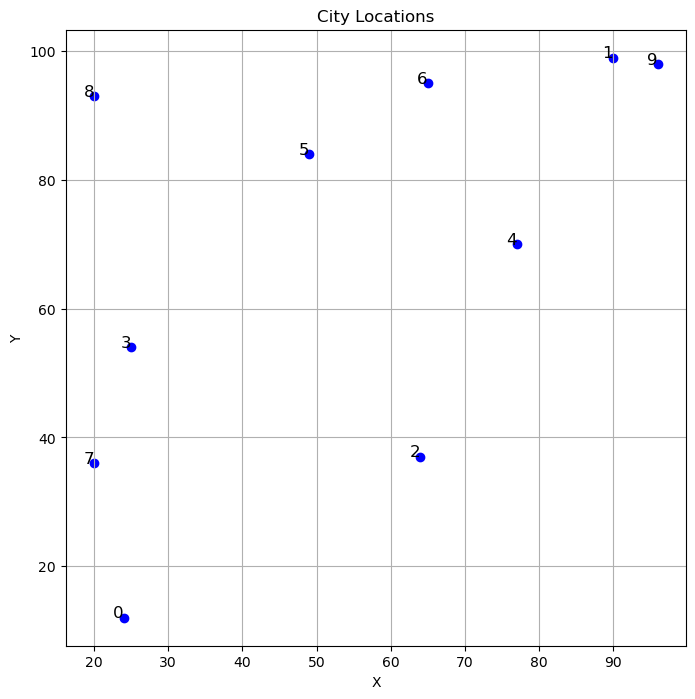

In [26]:
# 参数设定
# 模拟退火参数
T_0 = 100  # 初始温度
T_min = 1e-3  # 最低温度
q = 0.9  # 降温系数
max_iterations = 100  # 每个温度下的最大迭代次数

# TSP参数
size = 10
low_range = 0
high_range = 100
cities = create_cities(size, low_range, high_range)
best_route = np.zeros((0, size), dtype=int)  # 记录每次迭代的最优路径
best_distance = np.zeros(0)

distance_matrix = caculate_distance(cities)
plot_cities(cities)
# 初始化城市和距离矩阵

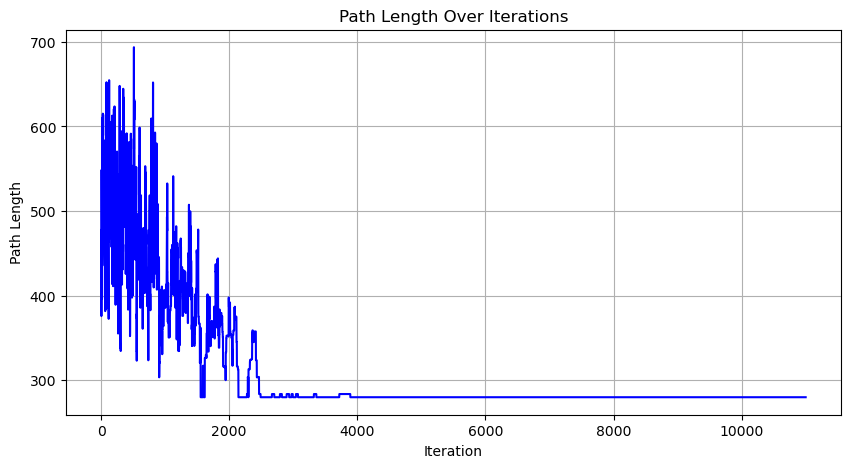

In [27]:
# 生成初始解
current_solution = generate_initial_solution(cities)
current_distance = caculate_path_distance(current_solution, distance_matrix)

# 模拟退火主循环
temperature = T_0
while temperature > T_min:
    for iteration in range(max_iterations):
        new_solution = generate_new_solution(current_solution)
        current_solution, current_distance = metropolis_criteria(current_solution, new_solution, distance_matrix, temperature)
        best_route = np.vstack([best_route, current_solution.flatten()])
        best_distance = np.append(best_distance, current_distance)
    temperature *= q

# 可视化路径长度记录
plot_distance_record(best_distance)

In [28]:
def plot_best_route(cities, best_route, title="TSP Optimal Route"):
    """
    绘制最优TSP路径
    
    参数:
    cities: 城市坐标数组，形状为(n, 2)
    best_route: 最优路径索引数组（如[0, 3, 1, 2, 0]或[0, 3, 1, 2]）
    title: 图表标题
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    plt.figure(figsize=(10, 8))
    
    # 确保路径是闭环
    if best_route[0] != best_route[-1]:
        route = np.append(best_route, best_route[0])
    else:
        route = best_route
    
    # 提取坐标
    route_coords = cities[route]
    
    # 绘制路径线
    plt.plot(route_coords[:, 0], route_coords[:, 1], 'b-', linewidth=2, alpha=0.7, zorder=3)
    
    # 绘制城市点
    plt.scatter(cities[:, 0], cities[:, 1], c='red', s=100, 
                edgecolors='black', linewidth=2, zorder=5)
    
    # 标记起点/终点
    plt.scatter(route_coords[0, 0], route_coords[0, 1], 
                c='green', s=200, marker='o', edgecolors='black', 
                linewidth=2, zorder=6, label='Start/End')
    
    # 显示城市编号
    for i, (x, y) in enumerate(cities):
        plt.text(x, y + 0.5, str(i), fontsize=12, ha='center', 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    # 计算总距离
    total_distance = 0
    for i in range(len(route) - 1):
        city_a = cities[route[i]]
        city_b = cities[route[i + 1]]
        total_distance += np.linalg.norm(city_a - city_b)
    
    plt.title(f"{title}\nTotal Distance: {total_distance:.2f}", fontsize=14, fontweight='bold')
    plt.xlabel("X Coordinate", fontsize=12)
    plt.ylabel("Y Coordinate", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    
    return plt

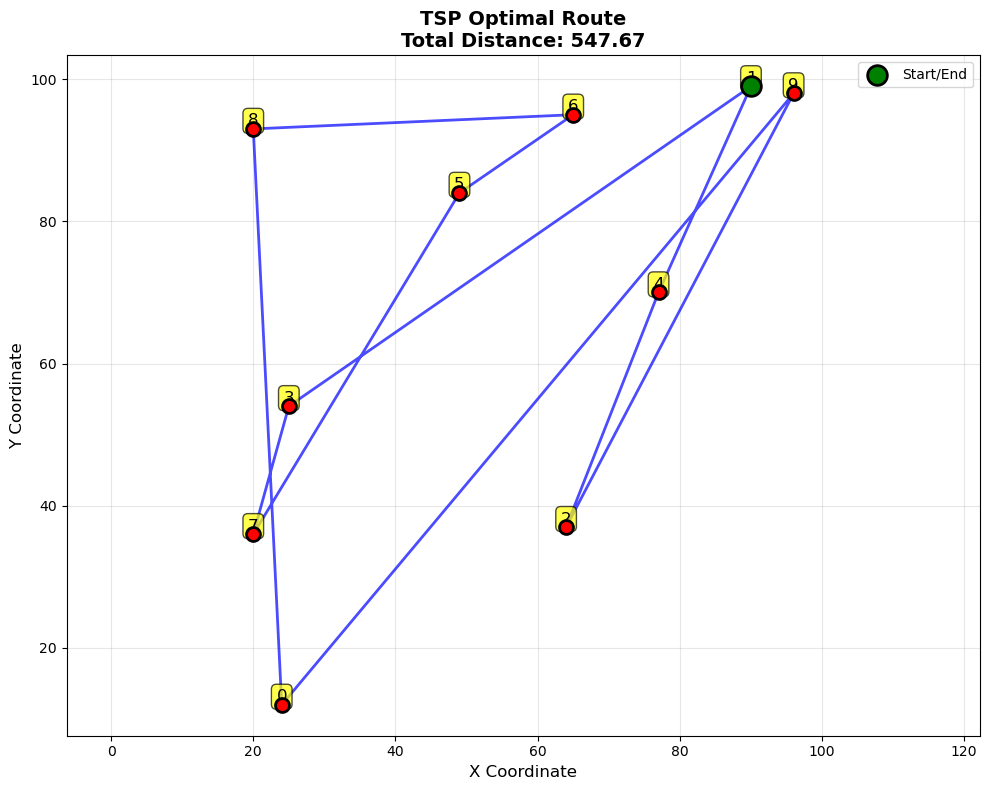

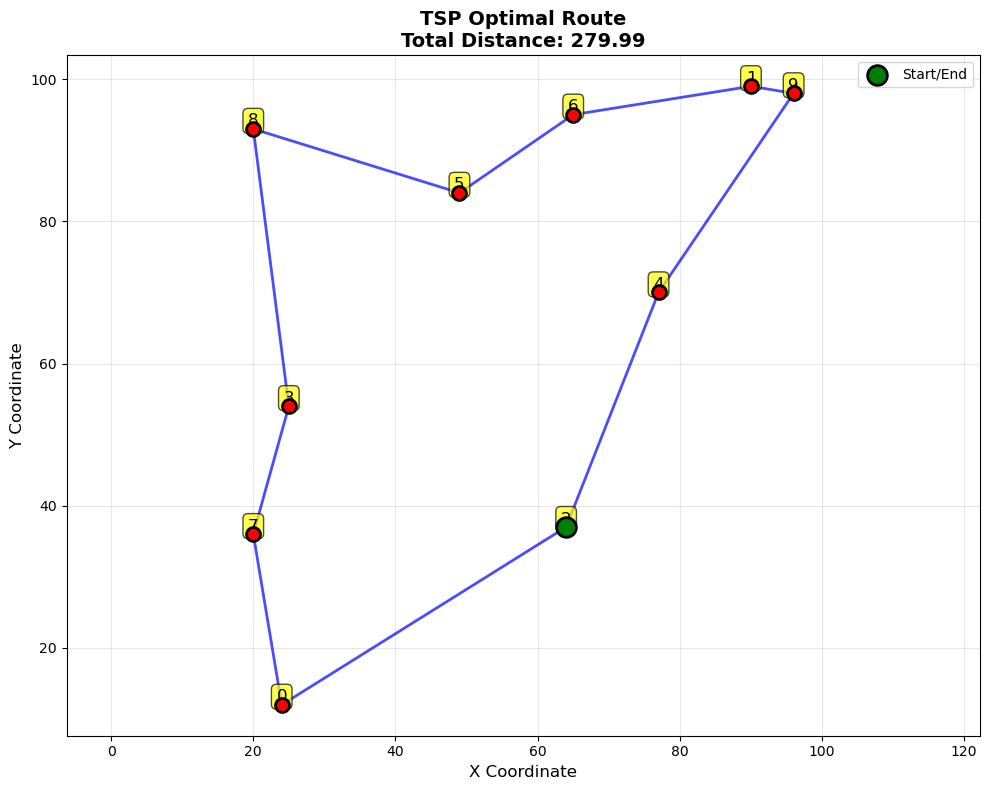

In [30]:
best_route_final = best_route[np.argmin(best_distance)]
best_route_1 = best_route[0]
plot_best_route(cities, best_route_1)
plt.show()
plot_best_route(cities, best_route_final)
plt.show()